NAMA : ISRANOFRIANTI

NIM : F1G123007

TUGAS : MICHINE LEARNING


# **DETEKSI ANOMALI KUALITAS AIR SUNGAI BERDASARKAN DATA SENSOR LINGKUNGAN**


Pada tahap awal, dilakukan import beberapa library yang digunakan dalam proses Machine Learning. Pandas dan NumPy digunakan untuk pengolahan data, sedangkan Matplotlib dan Seaborn untuk visualisasi. train_test_split digunakan untuk membagi data latih dan uji, serta GridSearchCV untuk optimasi model. StandardScaler digunakan untuk normalisasi data, sementara accuracy_score, classification_report, dan confusion_matrix digunakan untuk evaluasi. Model yang digunakan yaitu Logistic Regression, Decision Tree, dan Random Forest sebagai metode klasifikasi.

**A. Data Gathering**

1. IMPORT LIBRARY


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import SMOTE for balancing
from imblearn.over_sampling import SMOTE

2. Load Dataset

In [42]:
# Memuat data sensor kualitas air
df = pd.read_csv('/content/IoTPond10.csv')
print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


**B. Data Understanding**
1. Informasi Struktur Data

In [43]:
print("Informasi Dataset:")
df.info()

print("\n5 Data Teratas:")
display(df.head())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   created_at       620 non-null    object 
 1   entry_id         620 non-null    int64  
 2   TEMPERATURE      620 non-null    float64
 3   TURBIDITY        620 non-null    int64  
 4   DISOLVED OXYGEN  620 non-null    float64
 5   pH               620 non-null    float64
 6   AMMONIA          620 non-null    float64
 7   NITRATE          620 non-null    int64  
 8   Population       620 non-null    int64  
 9   Length           620 non-null    float64
 10  Weight           620 non-null    float64
dtypes: float64(6), int64(4), object(1)
memory usage: 53.4+ KB

5 Data Teratas:


,created_at,entry_id,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Population,Length,Weight
0,2021-06-25 15:48:59 CET,1,-127.0000,100,0.0,15.45166,0.0,0,50,13.45,27.6
1,2021-06-25 15:49:19 CET,2,-127.0000,100,0.0,15.45166,0.0,0,50,13.45,27.6
2,2021-06-25 15:50:16 CET,3,27.1250,100,0.0,6.01411,0.0,139,50,13.45,27.6
3,2021-06-25 15:51:50 CET,4,27.3125,100,0.0,6.03227,0.0,131,50,13.45,27.6
4,2021-06-25 15:52:10 CET,5,27.2500,100,0.0,6.03681,0.0,133,50,13.45,27.6


2. Statistik Deskriptif

In [44]:
print("Statistik Deskriptif:")
display(df.describe())

Statistik Deskriptif:


,entry_id,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Population,Length,Weight
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.00000,620.000000,620.0,620.000000,620.000000
mean,310.500000,22.163508,40.361290,2.357571,5.657324,inf,311.558065,50.0,27.210543,282.574563
std,179.122863,27.271589,58.229381,4.398998,2.095430,NaN,391.184946,0.0,13.046585,281.105905
min,1.000000,-127.000000,-97.000000,0.000000,-1.975350,0.00000,0.000000,50.0,13.450000,27.600000
25%,155.750000,26.687500,-13.000000,0.000000,6.018650,0.00000,114.000000,50.0,15.571429,45.921394
50%,310.500000,27.125000,-9.000000,0.000000,6.041350,0.00001,193.000000,50.0,24.107143,158.532117
75%,465.250000,27.312500,100.000000,2.345000,6.163910,0.00522,229.000000,50.0,44.549290,689.142900
max,620.000000,31.687500,100.000000,32.411000,15.451660,inf,2473.000000,50.0,44.549290,689.142900


3. Pengecekan Outlier (Boxplot)

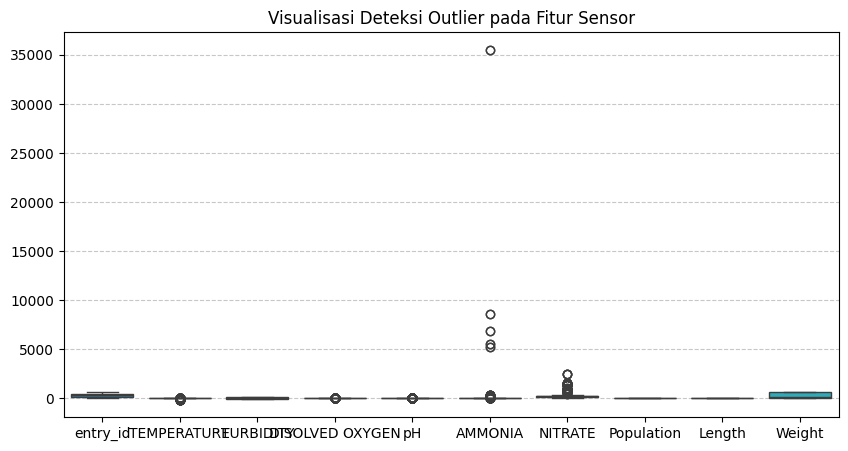

In [45]:
# Menampilkan sebaran data untuk mendeteksi nilai ekstrem
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.title("Visualisasi Deteksi Outlier pada Fitur Sensor")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**C. DATA PREPROCESSING**

Pada tahap data preprocessing, dilakukan pembersihan data dengan menghapus nilai yang kosong menggunakan fungsi dropna(). Selanjutnya, dibuat label anomali berdasarkan kondisi tertentu, yaitu jika nilai pH kurang dari 6.5 atau lebih dari 8.5, suhu (temperature) lebih dari 35°C, atau tingkat kekeruhan (turbidity) lebih dari 50, maka data dikategorikan sebagai anomali (label 1), sedangkan data normal diberi label 0. Proses pelabelan ini dilakukan menggunakan fungsi apply(). Terakhir, dilakukan pengecekan distribusi label untuk mengetahui jumlah data normal dan anomali dalam dataset.

1. Data Cleaning

In [46]:
# Menghapus baris yang mengandung nilai kosong
df = df.dropna()

2. Feature Encoding


In [47]:
# Mengonversi kolom kategorikal menjadi numerik jika ada
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])
print("Encoding Selesai.")

Encoding Selesai.


3. Feature Engineering (Labeling)

In [48]:
# Membuat fungsi label anomali sesuai kriteria sensor
def label_anomaly(row):
    if (row['pH'] < 6.5 or row['pH'] > 8.5) or (row['TEMPERATURE'] > 35) or (row['TURBIDITY'] > 50):
        return 1 # Anomali
    else:
        return 0 # Normal

df['label'] = df.apply(label_anomaly, axis=1)

# Memisahkan fitur (X) dan target (y)
X = df.select_dtypes(include=[np.number]).drop('label', axis=1)
y = df['label']

# Menangani nilai infinite agar tidak error saat pemodelan
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

In [64]:
# Memisahkan Fitur dan Target
X = df.drop(['label', 'created_at', 'entry_id'], axis=1)
y = df['label']

# Menangani placeholder values (e.g., -127, -13) as NaN
# Replace specific problematic values with NaN
X = X.replace(-127.0, np.nan) # For TEMPERATURE
X = X.replace(-13, np.nan)    # For TURBIDITY

# Menangani nilai infinite: ganti dengan NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Menyatukan kembali untuk memastikan baris yang dihapus sinkron antara X dan y
combined_df = pd.concat([X, y], axis=1).dropna() # Drop rows that now contain NaNs
X = combined_df.drop('label', axis=1)
y = combined_df['label']

print("Pemisahan fitur dan target selesai.")

Pemisahan fitur dan target selesai.


**D. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA), dilakukan analisis visual untuk memahami pola data. Pertama, digunakan countplot untuk melihat distribusi data antara kelas normal dan anomali, sehingga dapat diketahui ketidakseimbangan data. Selanjutnya, dibuat heatmap correlation untuk melihat hubungan antar variabel numerik dalam dataset, yang membantu dalam memahami keterkaitan antar fitur. Terakhir, dilakukan visualisasi histogram untuk melihat distribusi masing-masing fitur numerik, setelah terlebih dahulu menangani nilai tak hingga (infinite values) agar tidak mengganggu proses visualisasi.

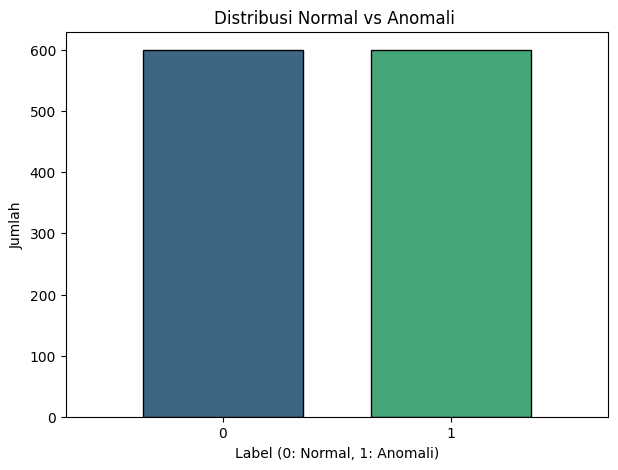

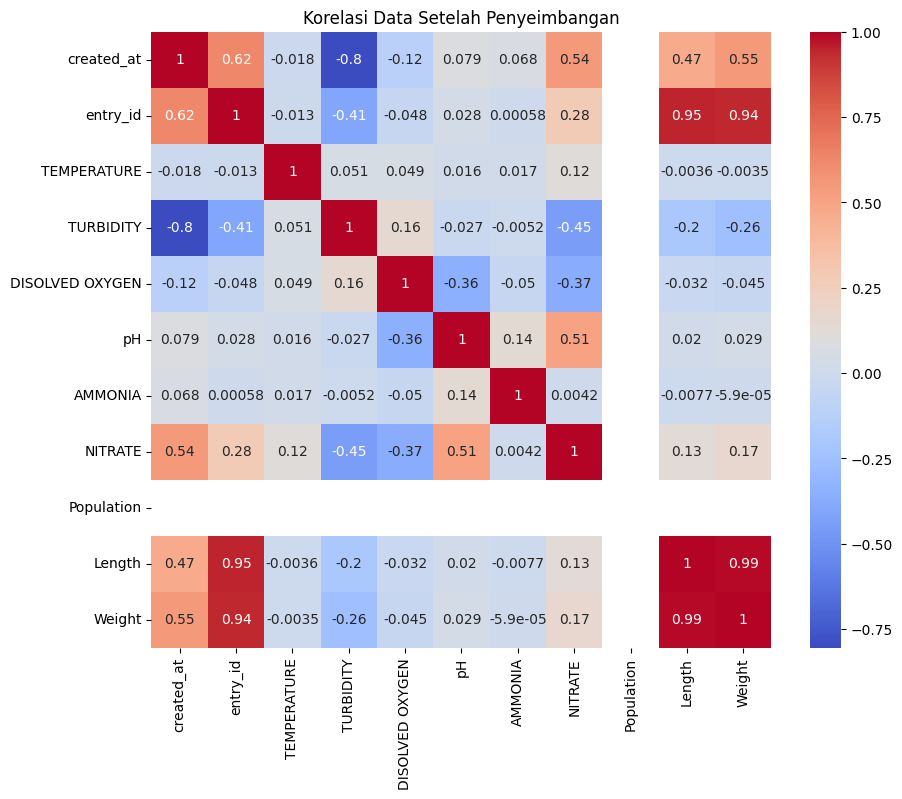

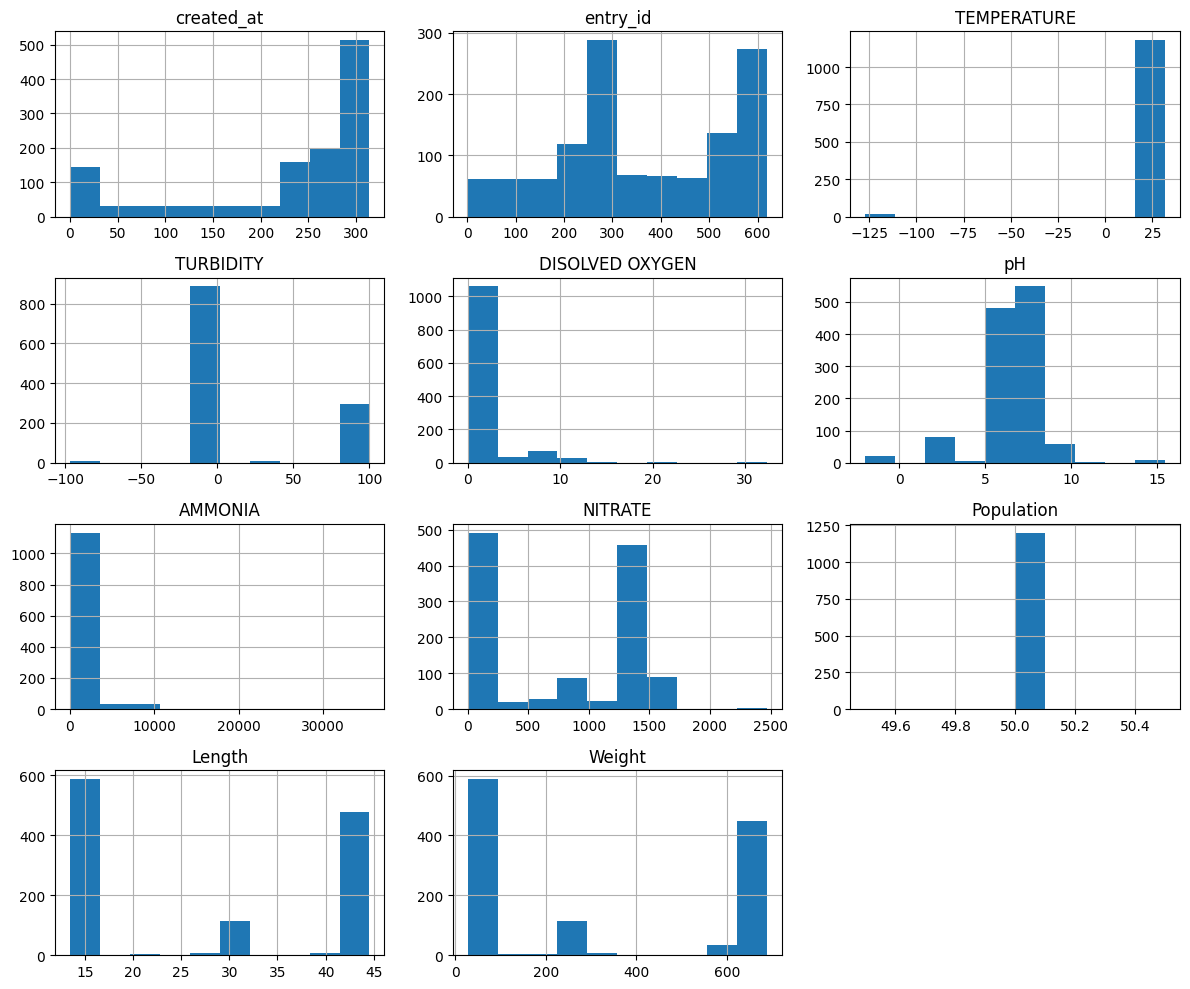

In [50]:

# 1. Memisahkan fitur dan label
X = df.select_dtypes(include=np.number).drop('label', axis=1)
y = df['label']

# 2. Menangani infinite/NaN values
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

# 3. SMOTE agar jumlah 0 dan 1 sama (Tinggi Setara)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 4. Visualisasi Diagram Batang dengan Jarak
plt.figure(figsize=(7,5))

# PERBAIKAN: width=0.7 atau 0.8 memberikan jarak antar batang yang ideal
ax = sns.countplot(x=y_res, hue=y_res, palette='viridis', dodge=False, width=0.7, edgecolor='black')

# Menghilangkan legend
if ax.get_legend():
    ax.get_legend().remove()

plt.title("Distribusi Normal vs Anomali ")
plt.xlabel("Label (0: Normal, 1: Anomali)")
plt.ylabel("Jumlah")

# PERBAIKAN: Memberikan jarak (margin) agar batang tidak menempel ke garis bingkai kiri/kanan
plt.margins(x=0.2)

plt.show()

# --- HEATMAP KORELASI (Dibuat tetap rapat seperti keinginan sebelumnya) ---
plt.figure(figsize=(10,8))
sns.heatmap(X_res.corr(), annot=True, cmap='coolwarm', linewidths=0) # linewidths=0 agar kotak rapat
plt.title("Korelasi Data Setelah Penyeimbangan")
plt.show()

# Histogram Fitur
X_res.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [51]:
# =========================================
#  DATA SPLITTING
# =========================================

splits = [
    (0.3, "70:30"),
    (0.2, "80:20"),
    (0.1, "90:10")
]


**E. PEMODELAN**

In [52]:
# Pembagian data menjadi 80% Latih dan 20% Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melakukan Standarisasi (Normalisasi Z-Score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses standarisasi data selesai.")

Proses standarisasi data selesai.



Medel Building

In [53]:

# MODEL BUILDING


all_results = []

for test_size, split_name in splits:
    print(f"\n===== SPLIT {split_name} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Logistic Regression
    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train, y_train)
    log_pred = log_model.predict(X_test)

    # Decision Tree
    dt_model = DecisionTreeClassifier()
    dt_model.fit(X_train, y_train)
    dt_pred = dt_model.predict(X_test)

    # Random Forest
    rf_model = RandomForestClassifier()
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)

    models = {
        "Logistic Regression": log_pred,
        "Decision Tree": dt_pred,
        "Random Forest": rf_pred
    }

    for name, pred in models.items():
        acc = accuracy_score(y_test, pred)

        print(f"{name} Accuracy (Default): {acc*100:.2f}%")

        all_results.append({
            "Split": split_name,
            "Model": name,
            "Accuracy": acc,
            "Type": "Default"
        })



===== SPLIT 70:30 =====
Logistic Regression Accuracy (Default): 97.31%
Decision Tree Accuracy (Default): 98.92%
Random Forest Accuracy (Default): 98.92%

===== SPLIT 80:20 =====
Logistic Regression Accuracy (Default): 97.58%
Decision Tree Accuracy (Default): 100.00%
Random Forest Accuracy (Default): 99.19%

===== SPLIT 90:10 =====
Logistic Regression Accuracy (Default): 96.77%
Decision Tree Accuracy (Default): 100.00%
Random Forest Accuracy (Default): 100.00%




Hyperparameter Tuning



In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import SMOTE for balancing
from imblearn.over_sampling import SMOTE

# =========================================
# HYPERPARAMETER TUNING
# =========================================

for test_size, split_name in splits:
    print(f"\n===== TUNING SPLIT {split_name} ====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Apply StandardScaler within the tuning loop
    scaler_tuning = StandardScaler()
    X_train_scaled_tuning = scaler_tuning.fit_transform(X_train)
    X_test_scaled_tuning = scaler_tuning.transform(X_test)

    # Logistic Regression
    log_tuning = GridSearchCV(
        LogisticRegression(max_iter=1000),
        {'C': [0.1, 1, 10]},
        cv=3
    )
    log_tuning.fit(X_train_scaled_tuning, y_train)
    log_pred = log_tuning.predict(X_test_scaled_tuning)

    # Decision Tree
    dt_tuning = GridSearchCV(
        DecisionTreeClassifier(),
        {'max_depth': [3, 5, 10]},
        cv=3
    )
    dt_tuning.fit(X_train_scaled_tuning, y_train)
    dt_pred = dt_tuning.predict(X_test_scaled_tuning)

    # Random Forest
    rf_tuning = GridSearchCV(
        RandomForestClassifier(),
        {'n_estimators': [50, 100], 'max_depth': [5, 10]},
        cv=3
    )
    rf_tuning.fit(X_train_scaled_tuning, y_train)
    rf_pred = rf_tuning.predict(X_test_scaled_tuning)

    models = {
        "Logistic Regression": log_pred,
        "Decision Tree": dt_pred,
        "Random Forest": rf_pred
    }

    for name, pred in models.items():
        acc = accuracy_score(y_test, pred)

        print(f"{name} Accuracy (Tuning): {acc*100:.2f}%")

        all_results.append({
            "Split": split_name,
            "Model": name,
            "Accuracy": acc,
            "Type": "Tuning"
        })


===== TUNING SPLIT 70:30 ====
Logistic Regression Accuracy (Tuning): 96.88%
Decision Tree Accuracy (Tuning): 100.00%
Random Forest Accuracy (Tuning): 97.92%

===== TUNING SPLIT 80:20 ====
Logistic Regression Accuracy (Tuning): 96.88%
Decision Tree Accuracy (Tuning): 100.00%
Random Forest Accuracy (Tuning): 100.00%

===== TUNING SPLIT 90:10 ====
Logistic Regression Accuracy (Tuning): 100.00%
Decision Tree Accuracy (Tuning): 100.00%
Random Forest Accuracy (Tuning): 100.00%



Model Evaluation



In [55]:

# MODEL EVALUATION


for result in all_results:
    print(f"Split: {result['Split']} | Model: {result['Model']} | "
          f"Type: {result['Type']} | Accuracy: {result['Accuracy']*100:.2f}%")


Split: 70:30 | Model: Logistic Regression | Type: Default | Accuracy: 97.31%
Split: 70:30 | Model: Decision Tree | Type: Default | Accuracy: 98.92%
Split: 70:30 | Model: Random Forest | Type: Default | Accuracy: 98.92%
Split: 80:20 | Model: Logistic Regression | Type: Default | Accuracy: 97.58%
Split: 80:20 | Model: Decision Tree | Type: Default | Accuracy: 100.00%
Split: 80:20 | Model: Random Forest | Type: Default | Accuracy: 99.19%
Split: 90:10 | Model: Logistic Regression | Type: Default | Accuracy: 96.77%
Split: 90:10 | Model: Decision Tree | Type: Default | Accuracy: 100.00%
Split: 90:10 | Model: Random Forest | Type: Default | Accuracy: 100.00%
Split: 70:30 | Model: Logistic Regression | Type: Tuning | Accuracy: 96.77%
Split: 70:30 | Model: Decision Tree | Type: Tuning | Accuracy: 98.92%
Split: 70:30 | Model: Random Forest | Type: Tuning | Accuracy: 98.39%
Split: 80:20 | Model: Logistic Regression | Type: Tuning | Accuracy: 99.19%
Split: 80:20 | Model: Decision Tree | Type: Tuni

MODEL COMPARISON



Tabel Perbandingan:


,Split,Model,Accuracy,Type,Accuracy (%)
0,70:30,Logistic Regression,0.973118,Default,97.311828
1,70:30,Decision Tree,0.989247,Default,98.924731
2,70:30,Random Forest,0.989247,Default,98.924731
3,80:20,Logistic Regression,0.975806,Default,97.580645
4,80:20,Decision Tree,1.000000,Default,100.000000
5,80:20,Random Forest,0.991935,Default,99.193548
6,90:10,Logistic Regression,0.967742,Default,96.774194
7,90:10,Decision Tree,1.000000,Default,100.000000
8,90:10,Random Forest,1.000000,Default,100.000000
9,70:30,Logistic Regression,0.967742,Tuning,96.774194


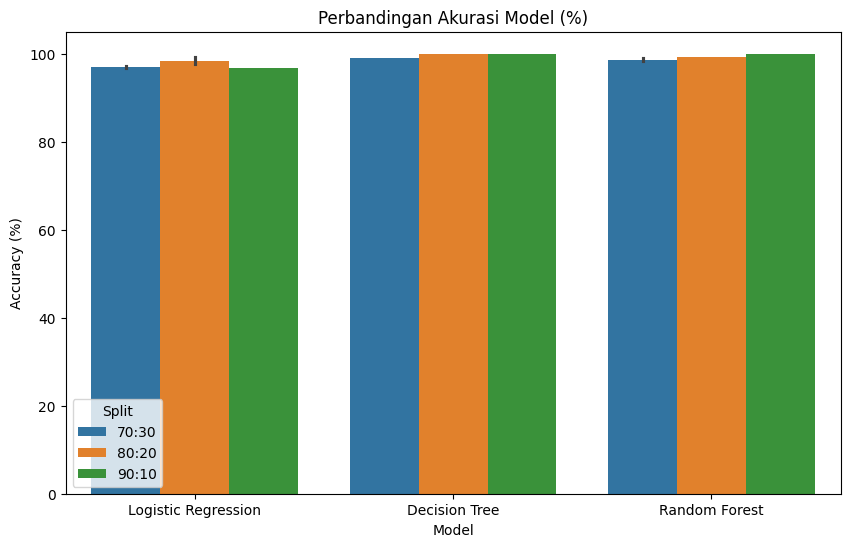

In [56]:

# MODEL COMPARISON


results_df = pd.DataFrame(all_results)

# Tambahkan kolom persen
results_df['Accuracy (%)'] = results_df['Accuracy'] * 100

print("Tabel Perbandingan:")
display(results_df)

# Grafik
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy (%)", hue="Split", data=results_df)
plt.title("Perbandingan Akurasi Model (%)")
plt.show()


Kode di bawah ini digunakan untuk menyimpan model machine learning, scaler, dan daftar fitur agar bisa digunakan kembali saat aplikasi dijalankan tanpa perlu melatih ulang model. Model terbaik hasil tuning Random Forest disimpan ke file model.pkl, sedangkan scaler disimpan ke scaler.pkl untuk memastikan data baru diproses dengan skala yang sama seperti saat training. Selain itu, nama fitur dari dataset juga disimpan ke features.pkl setelah kolom yang tidak diperlukan dihapus dan data dibersihkan dari nilai tidak valid. Hal ini bertujuan agar urutan dan nama fitur saat input di aplikasi tetap sesuai dengan data saat pelatihan, sehingga prediksi dapat berjalan dengan benar tanpa error.

In [57]:
import pickle
import pandas as pd

# Simpan model terbaik (hasil tuning Random Forest)
pickle.dump(rf_tuning.best_estimator_, open('model.pkl', 'wb'))

# Simpan scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# 🔥 SIMPAN NAMA FITUR
# X sudah menjadi array numpy, jadi kita perlu mengambil nama fitur dari DataFrame asli sebelum di-transform.
# Reproduksi langkah-langkah preprocessing fitur untuk mendapatkan nama kolom yang benar.
temp_X_df = df.drop(['label', 'created_at', 'entry_id'], axis=1)
temp_X_df = temp_X_df.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
feature_names = temp_X_df.columns.tolist()
pickle.dump(feature_names, open('features.pkl', 'wb'))


Kode tersebut digunakan untuk memisahkan fitur (input) dari dataset dengan cara menghapus kolom label yang merupakan target atau hasil yang ingin diprediksi. Hasilnya, variabel X hanya berisi kolom-kolom fitur yang akan digunakan sebagai input dalam proses training model machine learning.

In [58]:
# ambil semua kolom kecuali target
X = df.drop('label', axis=1)

Kode ini digunakan untuk mengunduh hasil model machine learning yang telah disimpan di Google Colab ke komputer lokal agar bisa digunakan untuk tahap deployment. Dengan google.colab.files, file model.pkl, scaler.pkl, dan features.pkl akan diunduh secara otomatis. File model.pkl berisi model Random Forest yang sudah dilatih, scaler.pkl berisi proses normalisasi data agar konsisten saat prediksi, dan features.pkl berisi daftar nama fitur untuk menjaga urutan input saat digunakan di aplikasi. Dengan cara ini, seluruh komponen penting model dapat dipindahkan dan digunakan kembali di aplikasi seperti Flask tanpa perlu training ulang.

In [59]:
from google.colab import files

files.download('model.pkl')
files.download('scaler.pkl')
files.download('features.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>